In [8]:
# loading all dependencies

import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
from fast_plate_ocr import LicensePlateRecognizer

In [9]:
# loading all infernce models

plate_finder = YOLO("plate_v2_35_epochs.pt")
m = LicensePlateRecognizer('cct-xs-v1-global-model')

*************** EP Error ***************
EP Error E:\_work\1\s\onnxruntime\python\onnxruntime_pybind_state.cc:559 onnxruntime::python::RegisterTensorRTPluginsAsCustomOps Please install TensorRT libraries as mentioned in the GPU requirements page, make sure they're in the PATH or LD_LIBRARY_PATH, and that your GPU is supported.
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CPUExecutionProvider'] and retrying.
****************************************


In [29]:
def read_licence_plates(img):
    # run plate inference
    plate_results = plate_finder.predict(source=img, 
                                         imgsz=640, 
                                         conf=0.72, 
                                         verbose=False)
    # draw bboxes
    for r in plate_results:
        boxes = r.boxes.xyxy.cpu().numpy()      
        confs = r.boxes.conf.cpu().numpy()      
        clss = r.boxes.cls.cpu().numpy().astype(int)

        for box, conf, cls in zip(boxes, confs, clss):
            x1, y1, x2, y2 = box.astype(int)
            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            else:
                plate_digits = str(m.run(crop))
                cv2.rectangle(
                    img,
                    (x1, y1),
                    (x2, y2),
                    (0, 255, 0),
                    2
                )
                cv2.putText(
                    img,
                    plate_digits,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.9,
                    (0, 255, 0),
                    2,
                    cv2.LINE_AA
                )
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 8))
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.show()

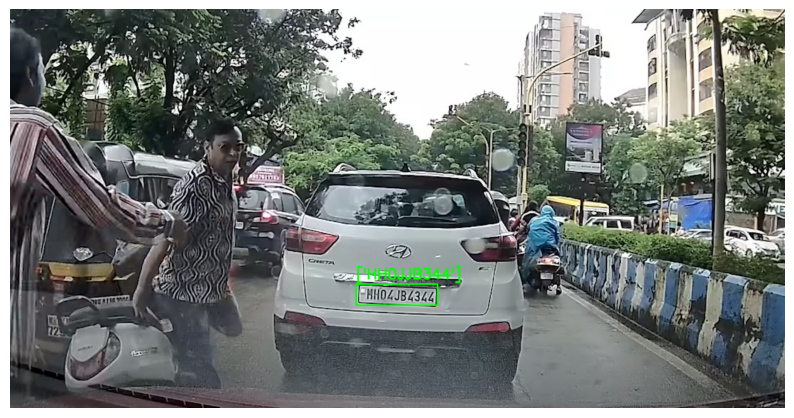

In [32]:
# test image

test_image = 'test_images/test22.jpg'
img = cv2.imread(test_image)
read_licence_plates(img)